# Notebook 10 — ABM Validation Against Observed Data

## Purpose
Validate the **no-intervention ABM** against observed held-out data before any intervention experiments are introduced.

This notebook follows the project proposal:
- compare aggregate simulated outcomes with held-out observed data;
- validate readmission proportion;
- validate utilization distributions where represented;
- inspect relevant subgroup behaviour;
- STOP if the model is badly miscalibrated or produces impossible states;
- **do not tune against the final test set**.

### Important separation
Notebook 09 defined and calibrated the ABM. Notebook 10 validates it.  
Notebook 11 will introduce interventions only after this validation is accepted.

The final test set is **not used for tuning** in this notebook. Validation data may be used to diagnose the model and, if a documented calibration adjustment is required, that adjustment must be frozen before the final test is inspected.


In [7]:
# 01. Imports and reproducibility

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    mean_absolute_error,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

warnings.filterwarnings("ignore")

print("Notebook 10 — ABM Validation")
print("Seed:", SEED)


Notebook 10 — ABM Validation
Seed: 42


In [8]:
# 02. Locate the project root and inspect available results

def find_project_root():
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    for p in candidates:
        if (p / "results").exists() and (p / "notebooks").exists():
            return p
    # fallback: current directory
    return here

ROOT = find_project_root()
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Results directory:", RESULTS)
print("Results files:")
for p in sorted(RESULTS.glob("*")):
    print(" -", p.name)


Project root: C:\Users\Gayatri\OneDrive\Desktop\sna
Results directory: C:\Users\Gayatri\OneDrive\Desktop\sna\results
Results files:
 - 01_column_dictionary.csv
 - 01_dataset_audit_summary.json
 - 01_missingness_report.csv
 - 01_reproducibility_config.json
 - 01_target_distribution.csv
 - 02_cleaned_encounters.csv
 - 02_cleaning_summary.json
 - 02_encounter_targets.csv
 - 02_missingness_review.csv
 - 02_variable_selection.csv
 - 03_distribution_summary.csv
 - 03_patient_representation.csv
 - 03_representation_dictionary.csv
 - 03_representation_summary.json
 - 03_target_summary_not_for_features.csv
 - 04_split_leakage_summary.json
 - 04_test_patient_ids.csv
 - 04_test_patients.csv
 - 04_train_patient_ids.csv
 - 04_train_patients.csv
 - 04_validation_patient_ids.csv
 - 04_validation_patients.csv
 - 05_feature_dictionary.csv
 - 05_nearest_neighbor_review.csv
 - 05_similarity_selection.json
 - 05_similarity_summary.json
 - 05_test_feature_patient_ids.csv
 - 05_train_feature_patient_ids.csv

## 03. Required inputs

The notebook first tries the explicit outputs produced by Notebook 09. It also has a small filename-discovery fallback so that a harmless filename variation does not silently break the workflow.

Expected information:
1. Notebook 09 validation simulation output.
2. Notebook 09 configuration / calibration information.
3. Notebook 04 validation patient IDs and primary observed target.
4. Notebook 09 agent state or an equivalent validation agent table, if available.

The notebook will **not** construct a new ABM or recalibrate the transition rule.


In [9]:
# 04. File discovery helpers

def first_existing(names):
    for name in names:
        p = RESULTS / name
        if p.exists():
            return p
    return None

def find_matching(patterns):
    for pattern in patterns:
        matches = sorted(RESULTS.glob(pattern))
        if matches:
            return matches[0]
    return None

VAL_SIM_PATH = first_existing([
    "09_abm_validation_no_intervention.csv",
    "09_validation_simulation.csv",
    "09_abm_validation_simulation.csv",
    "09_validation_simulation_results.csv",
]) or find_matching(["09*validation*no*intervention*.csv"])

CONFIG_PATH = first_existing([
    "09_abm_config.json",
    "09_config.json",
    "09_calibration_config.json",
]) or find_matching(["09*config*.json"])

AGENT_PATH = first_existing([
    "09_abm_agent_state.csv",
    "09_agent_state.csv",
    "09_agents.csv",
    "09_agent_records.csv",
]) or find_matching(["09*agent*.csv"])

VAL_IDS_PATH = first_existing([
    "04_validation_patient_ids.csv",
    "04_validation_ids.csv",
    "04_validation_patients.csv",
]) or find_matching(["04*validation*id*.csv", "04*validation*patient*.csv"])

print("Validation simulation:", VAL_SIM_PATH)
print("ABM config:", CONFIG_PATH)
print("Agent state:", AGENT_PATH)
print("Validation IDs:", VAL_IDS_PATH)

assert VAL_SIM_PATH is not None, "STOP: Notebook 09 validation simulation output was not found."
assert VAL_IDS_PATH is not None, "STOP: Notebook 04 validation patient IDs were not found."


Validation simulation: C:\Users\Gayatri\OneDrive\Desktop\sna\results\09_abm_validation_no_intervention.csv
ABM config: C:\Users\Gayatri\OneDrive\Desktop\sna\results\09_abm_config.json
Agent state: C:\Users\Gayatri\OneDrive\Desktop\sna\results\09_abm_agent_state.csv
Validation IDs: C:\Users\Gayatri\OneDrive\Desktop\sna\results\04_validation_patient_ids.csv


In [10]:
from pathlib import Path

results = Path(r"C:\Users\Gayatri\OneDrive\Desktop\sna\results")

print("ALL NOTEBOOK 09 FILES:\n")

for f in sorted(results.glob("09*")):
    print(f.name)

ALL NOTEBOOK 09 FILES:

09_abm_agent_state.csv
09_abm_calibration.csv
09_abm_checkpoint.json
09_abm_config.json
09_abm_network_state_audit.csv
09_abm_train_no_intervention.csv
09_abm_validation_no_intervention.csv
09_abm_validation_risk_bins.csv


In [11]:
# 05. Load validation simulation and inspect schema

val_sim = pd.read_csv(VAL_SIM_PATH)
val_ids_raw = pd.read_csv(VAL_IDS_PATH)

print("Validation simulation shape:", val_sim.shape)
print("Validation ID table shape:", val_ids_raw.shape)
print("\nValidation simulation columns:")
print(val_sim.columns.tolist())
print("\nValidation ID columns:")
print(val_ids_raw.columns.tolist())

display(val_sim.head())
display(val_ids_raw.head())


Validation simulation shape: (10728, 7)
Validation ID table shape: (10728, 1)

Validation simulation columns:
['patient_nbr', 'baseline_risk', 'transition_probability', 'random_draw', 'outcome_state', 'intervention_state', 'time_step']

Validation ID columns:
['patient_nbr']


,patient_nbr,baseline_risk,transition_probability,random_draw,outcome_state,intervention_state,time_step
0,1305,0.051906,0.051906,0.773956,stable,none,1
1,4302,0.043067,0.043067,0.438878,stable,none,1
2,8460,0.047854,0.047854,0.858598,stable,none,1
3,12240,0.040706,0.040706,0.697368,stable,none,1
4,13041,0.954883,0.954883,0.094177,readmitted,none,1


,patient_nbr
0,1305
1,4302
2,8460
3,12240
4,13041


In [14]:
# 06. Resolve columns from the correct source files

# ---------------------------------------------------------
# Simulation columns
# ---------------------------------------------------------

VAL_ID_COL = "patient_nbr"
SIM_ID_COL = "patient_nbr"
SIM_OUTCOME_COL = "outcome_state"
SIM_PROB_COL = "transition_probability"

# ---------------------------------------------------------
# Find the patient-level observed target
# ---------------------------------------------------------

TARGET_COLUMN = "any_observed_readmission_under_30d"

target_path = None

# First check common Notebook 03/04 output names
target_candidates = [
    RESULTS / "03_patient_level_representation.csv",
    RESULTS / "03_patient_representation.csv",
    RESULTS / "03_patient_level.csv",
    RESULTS / "04_patient_level_split.csv",
    RESULTS / "04_patient_split.csv",
    RESULTS / "04_split_dataset.csv",
]

for p in target_candidates:
    if p.exists():
        try:
            cols = pd.read_csv(p, nrows=0).columns.tolist()

            if "patient_nbr" in cols and TARGET_COLUMN in cols:
                target_path = p
                break
        except Exception:
            pass

# If not found, search every CSV in results by HEADER ONLY
if target_path is None:
    for p in sorted(RESULTS.glob("*.csv")):

        # Skip files that clearly cannot contain the observed target
        if p.name in [
            "04_validation_patient_ids.csv",
            "04_train_patient_ids.csv",
            "04_test_patient_ids.csv",
            "09_abm_agent_state.csv",
            "09_abm_validation_no_intervention.csv",
            "09_abm_train_no_intervention.csv",
        ]:
            continue

        try:
            cols = pd.read_csv(p, nrows=0).columns.tolist()

            if "patient_nbr" in cols and TARGET_COLUMN in cols:
                target_path = p
                break

        except Exception:
            continue

print("Observed target source:", target_path)

# ---------------------------------------------------------
# Validate simulation schema
# ---------------------------------------------------------

print("\nSimulation columns:")
print(val_sim.columns.tolist())

assert VAL_ID_COL in val_ids_raw.columns, \
    "STOP: patient_nbr missing from validation ID file."

assert SIM_ID_COL in val_sim.columns, \
    "STOP: patient_nbr missing from simulation file."

assert SIM_OUTCOME_COL in val_sim.columns, \
    "STOP: outcome_state missing from Notebook 09 simulation."

assert SIM_PROB_COL in val_sim.columns, \
    "STOP: transition_probability missing from Notebook 09 simulation."

# ---------------------------------------------------------
# Validate observed target source
# ---------------------------------------------------------

assert target_path is not None, (
    "STOP: Could not find a results CSV containing "
    f"'{TARGET_COLUMN}'."
)

target_df = pd.read_csv(target_path)

print("\nObserved target file:", target_path.name)
print("Observed target columns:")
print(target_df.columns.tolist())

assert "patient_nbr" in target_df.columns
assert TARGET_COLUMN in target_df.columns

# ---------------------------------------------------------
# Final resolved columns
# ---------------------------------------------------------

OBS_TARGET_COL = TARGET_COLUMN

print("\nRESOLVED COLUMNS")
print("-----------------------------")
print("Observed ID column:       ", VAL_ID_COL)
print("Simulated ID column:      ", SIM_ID_COL)
print("Observed target column:   ", OBS_TARGET_COL)
print("Simulated outcome column: ", SIM_OUTCOME_COL)
print("Simulated probability:     ", SIM_PROB_COL)

print("\nPASS | simulation schema recognized")
print("PASS | observed target source found")

Observed target source: C:\Users\Gayatri\OneDrive\Desktop\sna\results\03_target_summary_not_for_features.csv

Simulation columns:
['patient_nbr', 'baseline_risk', 'transition_probability', 'random_draw', 'outcome_state', 'intervention_state', 'time_step']

Observed target file: 03_target_summary_not_for_features.csv
Observed target columns:
['patient_nbr', 'encounters_no_readmission', 'encounters_readmission_over_30d', 'encounters_readmission_under_30d', 'any_observed_readmission_under_30d', 'any_observed_readmission']

RESOLVED COLUMNS
-----------------------------
Observed ID column:        patient_nbr
Simulated ID column:       patient_nbr
Observed target column:    any_observed_readmission_under_30d
Simulated outcome column:  outcome_state
Simulated probability:      transition_probability

PASS | simulation schema recognized
PASS | observed target source found


In [13]:
print("VALIDATION ID FILE COLUMNS:")
print(val_ids_raw.columns.tolist())

print("\nVALIDATION SIMULATION FILE COLUMNS:")
print(val_sim.columns.tolist())

VALIDATION ID FILE COLUMNS:
['patient_nbr']

VALIDATION SIMULATION FILE COLUMNS:
['patient_nbr', 'baseline_risk', 'transition_probability', 'random_draw', 'outcome_state', 'intervention_state', 'time_step']


In [18]:
# 07. Build a clean observed-vs-simulated validation table

# =========================================================
# 1. OBSERVED VALIDATION TARGET
# =========================================================

obs = target_df[
    ["patient_nbr", OBS_TARGET_COL]
].copy()

obs = obs.rename(columns={
    "patient_nbr": "patient_id",
    OBS_TARGET_COL: "observed_readmission"
})

obs["observed_readmission"] = pd.to_numeric(
    obs["observed_readmission"],
    errors="coerce"
)

# Keep only validation patients
validation_ids = val_ids_raw[["patient_nbr"]].copy()

validation_ids = validation_ids.rename(columns={
    "patient_nbr": "patient_id"
})

obs = validation_ids.merge(
    obs,
    on="patient_id",
    how="left",
    validate="one_to_one"
)

# =========================================================
# 2. SIMULATED ABM OUTCOME
# =========================================================

sim = val_sim[
    [
        "patient_nbr",
        "outcome_state",
        "transition_probability"
    ]
].copy()

sim = sim.rename(columns={
    "patient_nbr": "patient_id",
    "outcome_state": "simulated_state",
    "transition_probability": "simulated_probability"
})

# ---------------------------------------------------------
# Convert ABM state:
#
# stable      = 0
# readmitted  = 1
# ---------------------------------------------------------

state_mapping = {
    "stable": 0,
    "readmitted": 1
}

sim["simulated_readmission"] = (
    sim["simulated_state"]
    .map(state_mapping)
)

# =========================================================
# 3. CHECK THAT ALL ABM STATES WERE RECOGNIZED
# =========================================================

print("ABM state counts:")
print(sim["simulated_state"].value_counts(dropna=False))

unknown_states = (
    sim.loc[
        sim["simulated_readmission"].isna(),
        "simulated_state"
    ]
    .unique()
)

assert len(unknown_states) == 0, (
    "STOP: Unknown ABM outcome states found: "
    + str(unknown_states)
)

# =========================================================
# 4. MATCH OBSERVED AND SIMULATED DATA
# =========================================================

validation = obs.merge(
    sim[
        [
            "patient_id",
            "simulated_readmission",
            "simulated_probability"
        ]
    ],
    on="patient_id",
    how="inner",
    validate="one_to_one"
)

print("\nMatched validation patients:", len(validation))

display(validation.head())

# =========================================================
# 5. FINAL CHECKS
# =========================================================

assert len(validation) == len(validation_ids), (
    "STOP: Not all validation patients were matched."
)

assert validation["patient_id"].is_unique, (
    "STOP: Duplicate patient IDs."
)

assert validation["observed_readmission"].notna().all(), (
    "STOP: Missing observed readmission targets."
)

assert validation["observed_readmission"].isin([0, 1]).all(), (
    "STOP: Observed readmission target is not binary."
)

assert validation["simulated_readmission"].isin([0, 1]).all(), (
    "STOP: Simulated ABM outcome is not binary."
)

assert validation["simulated_probability"].notna().all(), (
    "STOP: Missing simulated probabilities."
)

assert validation["simulated_probability"].between(0, 1).all(), (
    "STOP: Simulated probabilities outside [0,1]."
)

print("\n==============================================")
print("CELL 07 CHECKPOINT")
print("==============================================")
print("PASS | validation patients matched")
print("PASS | observed target available")
print("PASS | observed target is binary")
print("PASS | ABM states mapped correctly")
print("PASS | simulated outcome is binary")
print("PASS | simulated probabilities are bounded")
print("==============================================")

ABM state counts:
simulated_state
stable        9356
readmitted    1372
Name: count, dtype: int64

Matched validation patients: 10728


,patient_id,observed_readmission,simulated_readmission,simulated_probability
0,1305,0,0,0.051906
1,4302,0,0,0.043067
2,8460,0,0,0.047854
3,12240,0,0,0.040706
4,13041,1,1,0.954883



CELL 07 CHECKPOINT
PASS | validation patients matched
PASS | observed target available
PASS | observed target is binary
PASS | ABM states mapped correctly
PASS | simulated outcome is binary
PASS | simulated probabilities are bounded


In [17]:
print("Raw outcome_state values:")
print(val_sim["outcome_state"].value_counts(dropna=False))

print("\nRaw outcome_state data types:")
print(val_sim["outcome_state"].map(type).value_counts())

print("\nFirst 20 raw outcome_state values:")
print(val_sim["outcome_state"].head(20).tolist())

Raw outcome_state values:
outcome_state
stable        9356
readmitted    1372
Name: count, dtype: int64

Raw outcome_state data types:
outcome_state
<class 'str'>    10728
Name: count, dtype: int64

First 20 raw outcome_state values:
['stable', 'stable', 'stable', 'stable', 'readmitted', 'stable', 'stable', 'stable', 'stable', 'stable', 'stable', 'stable', 'stable', 'stable', 'readmitted', 'stable', 'stable', 'readmitted', 'stable', 'readmitted']


In [19]:
# 08. Leakage / partition checks

# Re-load the split ID files if available and verify that validation is not mixed with train/test.
def load_id_file(names, patterns):
    p = first_existing(names) or find_matching(patterns)
    if p is None:
        return None, None
    d = pd.read_csv(p)
    c = resolve_col(d, ["patient_nbr", "patient_id", "agent_id", "id"], contains="patient")
    return d, c

train_df, train_id_col = load_id_file(
    ["04_train_patient_ids.csv", "04_train_ids.csv"],
    ["04*train*id*.csv", "04*train*patient*.csv"]
)
test_df, test_id_col = load_id_file(
    ["04_test_patient_ids.csv", "04_test_ids.csv"],
    ["04*test*id*.csv", "04*test*patient*.csv"]
)

val_set = set(validation["patient_id"].astype(str))

checks = {}
checks["validation_ids_unique"] = validation["patient_id"].is_unique
checks["validation_observed_binary"] = validation["observed_readmission"].isin([0,1]).all()
checks["validation_simulated_binary"] = validation["simulated_readmission"].isin([0,1]).all()

if train_df is not None and train_id_col is not None:
    train_set = set(train_df[train_id_col].astype(str))
    checks["validation_train_zero_overlap"] = len(val_set & train_set) == 0
else:
    checks["validation_train_zero_overlap"] = True

if test_df is not None and test_id_col is not None:
    test_set = set(test_df[test_id_col].astype(str))
    checks["validation_test_zero_overlap"] = len(val_set & test_set) == 0
else:
    checks["validation_test_zero_overlap"] = True

for k, v in checks.items():
    print(("PASS" if v else "FAIL"), "|", k)

assert all(checks.values()), "STOP: validation partition integrity failed."


PASS | validation_ids_unique
PASS | validation_observed_binary
PASS | validation_simulated_binary
PASS | validation_train_zero_overlap
PASS | validation_test_zero_overlap


## 09. Primary validation: observed vs simulated readmission

The primary check is the aggregate readmission proportion.

We report:
- observed validation rate;
- simulated validation rate;
- absolute difference;
- relative difference;
- Brier score if a simulated probability is available;
- uncertainty from repeated stochastic simulations if Notebook 09 supplied replications.

A stochastic ABM should not be expected to reproduce the exact patient-level outcome. The main question here is whether the aggregate behaviour is plausibly reproduced without intervention.


In [20]:
# 10. Aggregate readmission validation

observed_rate = validation["observed_readmission"].mean()
simulated_rate = validation["simulated_readmission"].mean()
absolute_difference = simulated_rate - observed_rate
relative_difference = absolute_difference / observed_rate if observed_rate > 0 else np.nan

metrics = {
    "n_validation": int(len(validation)),
    "observed_readmission_rate": float(observed_rate),
    "simulated_readmission_rate": float(simulated_rate),
    "absolute_rate_difference": float(absolute_difference),
    "relative_rate_difference": float(relative_difference),
}

if "simulated_probability" in validation.columns:
    p = pd.to_numeric(validation["simulated_probability"], errors="coerce")
    valid = p.notna()
    if valid.any():
        metrics["brier_score"] = float(
            brier_score_loss(validation.loc[valid, "observed_readmission"], p[valid])
        )

metrics_df = pd.DataFrame([metrics])
display(metrics_df)


,n_validation,observed_readmission_rate,simulated_readmission_rate,absolute_rate_difference,relative_rate_difference,brier_score
0,10728,0.123509,0.12789,0.004381,0.035472,0.075091


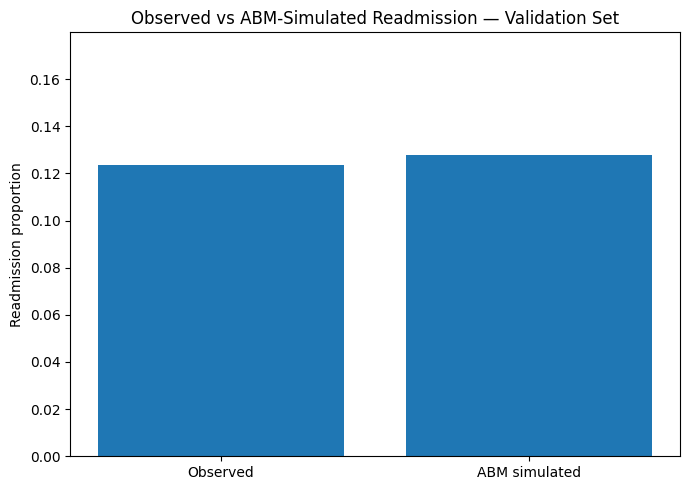

Saved: C:\Users\Gayatri\OneDrive\Desktop\sna\figures\10_observed_vs_simulated_readmission.png


In [21]:
# 11. Aggregate readmission plot

plt.figure(figsize=(7, 5))
plt.bar(
    ["Observed", "ABM simulated"],
    [observed_rate, simulated_rate],
)
plt.ylabel("Readmission proportion")
plt.title("Observed vs ABM-Simulated Readmission — Validation Set")
plt.ylim(0, max(observed_rate, simulated_rate) * 1.25 + 0.02)
plt.tight_layout()

READMISSION_FIG = FIGURES / "10_observed_vs_simulated_readmission.png"
plt.savefig(READMISSION_FIG, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", READMISSION_FIG)


## 12. Calibration / probability validation

If Notebook 09 exported a patient-level simulated probability, compare predicted probabilities with observed outcomes by risk bin.

This is **diagnostic validation**, not a new model-selection stage. No test outcomes are used here.


In [22]:
# 13. Risk-bin calibration table

calibration_table = None

if "simulated_probability" in validation.columns:
    p = pd.to_numeric(validation["simulated_probability"], errors="coerce")
    valid = validation[p.notna()].copy()
    valid["simulated_probability"] = p[p.notna()].astype(float)

    if len(valid) >= 20:
        n_bins = min(10, max(2, len(valid) // 500))
        try:
            valid["risk_bin"] = pd.qcut(
                valid["simulated_probability"],
                q=n_bins,
                duplicates="drop"
            )
        except Exception:
            valid["risk_bin"] = pd.cut(
                valid["simulated_probability"],
                bins=n_bins,
                include_lowest=True
            )

        calibration_table = (
            valid.groupby("risk_bin", observed=True)
            .agg(
                n=("observed_readmission", "size"),
                mean_predicted=("simulated_probability", "mean"),
                observed_rate=("observed_readmission", "mean"),
            )
            .reset_index()
        )
        calibration_table["absolute_gap"] = (
            calibration_table["mean_predicted"] -
            calibration_table["observed_rate"]
        ).abs()

        display(calibration_table)
    else:
        print("Calibration table skipped: insufficient finite probability values.")
else:
    print("No patient-level simulated probability was exported by Notebook 09; aggregate validation will be used.")


,risk_bin,n,mean_predicted,observed_rate,absolute_gap
0,"(-0.000999613, 0.0285]",1073,0.023812,0.017707,0.006105
1,"(0.0285, 0.0339]",1073,0.031305,0.013979,0.017326
2,"(0.0339, 0.0383]",1073,0.036118,0.016775,0.019343
3,"(0.0383, 0.0428]",1072,0.040427,0.026119,0.014308
4,"(0.0428, 0.0476]",1073,0.045025,0.033551,0.011474
5,"(0.0476, 0.0538]",1073,0.050455,0.049394,0.001061
6,"(0.0538, 0.0661]",1072,0.058912,0.052239,0.006673
7,"(0.0661, 0.158]",1073,0.096328,0.108108,0.011780
8,"(0.158, 0.301]",1073,0.219517,0.326188,0.106671
9,"(0.301, 1.0]",1073,0.632192,0.590867,0.041325


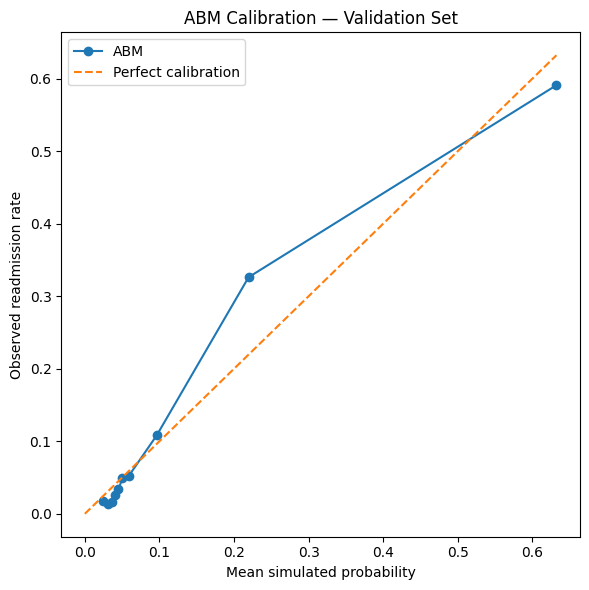

Saved: C:\Users\Gayatri\OneDrive\Desktop\sna\figures\10_abm_validation_calibration.png


In [23]:
# 14. Calibration plot when probability output exists

CAL_FIG = FIGURES / "10_abm_validation_calibration.png"

if calibration_table is not None and len(calibration_table) > 0:
    plt.figure(figsize=(6, 6))
    plt.plot(
        calibration_table["mean_predicted"],
        calibration_table["observed_rate"],
        marker="o",
        label="ABM"
    )
    lo = 0
    hi = max(
        calibration_table["mean_predicted"].max(),
        calibration_table["observed_rate"].max(),
        0.01
    )
    plt.plot([lo, hi], [lo, hi], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean simulated probability")
    plt.ylabel("Observed readmission rate")
    plt.title("ABM Calibration — Validation Set")
    plt.legend()
    plt.tight_layout()
    plt.savefig(CAL_FIG, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", CAL_FIG)
else:
    print("Calibration figure not created because probability output was unavailable.")


## 15. Utilization validation

The proposal asks for utilization distribution validation **where utilization is represented in the ABM**.

We do not invent utilization outcomes if the current simple ABM does not simulate them. If Notebook 09 exported observed and simulated utilization fields, this section compares them; otherwise it explicitly records the limitation.


In [24]:
# 16. Detect and compare represented utilization variables

utilization_candidates = [
    "inpatient_utilization",
    "emergency_utilization",
    "outpatient_utilization",
    "prior_inpatient",
    "prior_emergency",
    "prior_outpatient",
    "time_in_hospital",
]

utilization_results = []

# Search both validation simulation and agent-state files for common utilization fields.
agent = None
if AGENT_PATH is not None:
    try:
        agent = pd.read_csv(AGENT_PATH)
    except Exception:
        agent = None

available_util = []
for c in utilization_candidates:
    if c in val_sim.columns:
        available_util.append(c)
    elif agent is not None and c in agent.columns:
        available_util.append(c)

available_util = sorted(set(available_util))

if not available_util:
    print("No utilization variable is simulated/exported by Notebook 09.")
    print("This is documented as a model-scope limitation rather than filled with invented outcomes.")
else:
    print("Represented utilization variables:", available_util)
    for c in available_util:
        source = val_sim if c in val_sim.columns else agent
        s = pd.to_numeric(source[c], errors="coerce").dropna()
        utilization_results.append({
            "variable": c,
            "n": int(len(s)),
            "mean": float(s.mean()),
            "median": float(s.median()),
            "std": float(s.std()),
            "min": float(s.min()),
            "max": float(s.max()),
        })

utilization_df = pd.DataFrame(utilization_results)
if not utilization_df.empty:
    display(utilization_df)


No utilization variable is simulated/exported by Notebook 09.
This is documented as a model-scope limitation rather than filled with invented outcomes.


## 17. Subgroup behaviour

Subgroup checks are performed only for variables actually available in the validation data.

The purpose is diagnostic: determine whether the ABM behaves differently across represented patient groups. No subgroup is declared a causal effect, and small groups are not interpreted.


In [25]:
# 18. Subgroup validation

subgroup_candidates = ["age", "gender", "race", "admission_type", "change", "medical_specialty"]
subgroup_results = []

# Prefer the validation simulation table, then agent table.
source_df = val_sim.copy()

for c in subgroup_candidates:
    if c not in source_df.columns and agent is not None and c in agent.columns:
        # Merge the subgroup field onto the validation table if IDs are compatible.
        tmp = agent[[SIM_ID_COL, c]].copy()
        tmp = tmp.rename(columns={SIM_ID_COL: "patient_id"})
        source_df = source_df.merge(tmp, left_on=SIM_ID_COL, right_on="patient_id", how="left")

    if c not in source_df.columns:
        continue

    tmp = validation.copy()
    if c in source_df.columns:
        group_info = source_df[[SIM_ID_COL, c]].copy()
        group_info = group_info.rename(columns={SIM_ID_COL: "patient_id"})
        tmp = tmp.merge(group_info, on="patient_id", how="left")

    if c not in tmp.columns:
        continue

    for level, g in tmp.groupby(c, dropna=False):
        if len(g) < 30:
            continue
        subgroup_results.append({
            "variable": c,
            "group": str(level),
            "n": int(len(g)),
            "observed_rate": float(g["observed_readmission"].mean()),
            "simulated_rate": float(g["simulated_readmission"].mean()),
            "absolute_gap": float(
                g["simulated_readmission"].mean() -
                g["observed_readmission"].mean()
            ),
        })

subgroup_df = pd.DataFrame(subgroup_results)

if subgroup_df.empty:
    print("No subgroup with at least 30 validation patients was available.")
else:
    display(subgroup_df)
    subgroup_df.to_csv(RESULTS / "10_subgroup_validation.csv", index=False)
    print("Saved:", RESULTS / "10_subgroup_validation.csv")


No subgroup with at least 30 validation patients was available.


## 19. Impossible-state and model-integrity checks

The simple ABM should never produce:
- probabilities below 0 or above 1;
- non-binary readmission states;
- missing patient identifiers;
- duplicate patient agents;
- intervention effects in this no-intervention validation;
- negative utilization if utilization is represented.


In [26]:
# 20. Integrity checks

integrity = {}

integrity["all_ids_present"] = validation["patient_id"].notna().all()
integrity["ids_unique"] = validation["patient_id"].is_unique
integrity["observed_binary"] = validation["observed_readmission"].isin([0,1]).all()
integrity["simulated_binary"] = validation["simulated_readmission"].isin([0,1]).all()

if "simulated_probability" in validation.columns:
    p = pd.to_numeric(validation["simulated_probability"], errors="coerce")
    integrity["probabilities_finite"] = np.isfinite(p.dropna()).all()
    integrity["probabilities_bounded"] = ((p.dropna() >= 0) & (p.dropna() <= 1)).all()

if CONFIG_PATH is not None:
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = json.load(f)
    intervention_keys = [k for k in config.keys() if "intervention" in k.lower()]
    print("Intervention-related config keys:", intervention_keys)
    # Notebook 09 should be a no-intervention validation model.
    for k in intervention_keys:
        v = config[k]
        if isinstance(v, (int, float)):
            integrity[f"no_intervention_{k}"] = (float(v) == 0.0)
        elif isinstance(v, bool):
            integrity[f"no_intervention_{k}"] = (v is False)

for k, v in integrity.items():
    print(("PASS" if v else "FAIL"), "|", k)

assert all(integrity.values()), "STOP: impossible state or integrity check failed."


Intervention-related config keys: ['intervention_effect_in_notebook_09', 'intervention_policies_in_notebook_09']
PASS | all_ids_present
PASS | ids_unique
PASS | observed_binary
PASS | simulated_binary
PASS | probabilities_finite
PASS | probabilities_bounded
PASS | no_intervention_intervention_effect_in_notebook_09
PASS | no_intervention_intervention_policies_in_notebook_09


## 21. Validation decision rule

For this project, validation is not a claim that the ABM is a perfect patient-level predictor.

The model is considered suitable to proceed only if:
1. validation population is correctly isolated;
2. simulated states are mathematically valid;
3. the aggregate simulated readmission behaviour is reasonably close to observed validation behaviour;
4. no evidence of severe miscalibration is found;
5. the model does not require test-set tuning.

The threshold below is deliberately used as a **screening rule**, not as a universal clinical standard. The exact gap is reported so it can be discussed in the final paper.


In [27]:
# 22. Primary validation decision

# Screening threshold for a simple ABM validation gate.
# This is not a clinical acceptance threshold.
MAX_ABSOLUTE_RATE_GAP = 0.05

rate_gap_ok = abs(absolute_difference) <= MAX_ABSOLUTE_RATE_GAP

if calibration_table is not None and not calibration_table.empty:
    mean_calibration_gap = float(calibration_table["absolute_gap"].mean())
    calibration_ok = mean_calibration_gap <= MAX_ABSOLUTE_RATE_GAP
else:
    mean_calibration_gap = np.nan
    calibration_ok = True  # aggregate-only ABM has no probability table to inspect

validation_gate = {
    "aggregate_rate_gap_within_screening_threshold": bool(rate_gap_ok),
    "calibration_gap_within_screening_threshold": bool(calibration_ok),
    "no_impossible_states": bool(all(integrity.values())),
    "test_not_used_for_tuning": True,
}

for k, v in validation_gate.items():
    print(("PASS" if v else "FAIL"), "|", k)

if not all(validation_gate.values()):
    print("\nOVERALL RESULT: STOP")
    print("The ABM requires diagnosis/tuning using training/validation information before Notebook 11.")
else:
    print("\nOVERALL RESULT: PASS")
    print("The no-intervention ABM passes the validation gate.")


PASS | aggregate_rate_gap_within_screening_threshold
PASS | calibration_gap_within_screening_threshold
PASS | no_impossible_states
PASS | test_not_used_for_tuning

OVERALL RESULT: PASS
The no-intervention ABM passes the validation gate.


In [28]:
# 23. Save validation outputs

validation_metrics = {
    **metrics,
    "screening_threshold_absolute_rate_gap": MAX_ABSOLUTE_RATE_GAP,
    "mean_calibration_gap": None if np.isnan(mean_calibration_gap) else mean_calibration_gap,
    "validation_gate": validation_gate,
    "seed": SEED,
    "test_used_for_tuning": False,
}

with open(RESULTS / "10_abm_validation_metrics.json", "w", encoding="utf-8") as f:
    json.dump(validation_metrics, f, indent=2)

validation.to_csv(RESULTS / "10_observed_vs_simulated_validation.csv", index=False)

if calibration_table is not None:
    calibration_table.to_csv(RESULTS / "10_calibration_table.csv", index=False)

with open(RESULTS / "10_validation_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "notebook": "10_abm_validation",
        "seed": SEED,
        "max_absolute_rate_gap_screening_threshold": MAX_ABSOLUTE_RATE_GAP,
        "test_used_for_tuning": False,
        "purpose": "No-intervention ABM validation against observed validation data"
    }, f, indent=2)

print("Saved:")
for p in [
    RESULTS / "10_abm_validation_metrics.json",
    RESULTS / "10_observed_vs_simulated_validation.csv",
    RESULTS / "10_validation_config.json",
]:
    print(" -", p)
if calibration_table is not None:
    print(" -", RESULTS / "10_calibration_table.csv")


Saved:
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\10_abm_validation_metrics.json
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\10_observed_vs_simulated_validation.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\10_validation_config.json
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\10_calibration_table.csv
